In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

## 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 가져옴

In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist #mnist 훈련셋과 테스트셋
from tensorflow.keras.utils import to_categorical #원핫인코딩
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt #학습과정 loss와 acc시각화
# quiz에서는 scale조정, train_test_split 등을 추가

In [2]:
import numpy as np
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [4]:
print('타켓:', data[0,0])
#print('이미지(28*28을 1차원으로):', data[0,1:]).reshape(28, 28)

타켓: 5.0


In [5]:
for row in data [1, 1:].reshape(28,28):
    for pixel in row:
        print('{:3.0f}'.format(pixel), end='')
    print()

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 51159253159 50  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 48238252252252237  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0 54227253252239233252 57  6  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 10 60224252253252202 84252253122  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0163252252252253252252 96189253167  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0 51238253253190114253228 47 79255168  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 48238252252179 12 75121 21  0  0253243 50  0  0  0  0  0
  0  0  0  0  0  0  0  0 38165253233208 84  0  0  0  0  0  025325

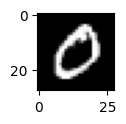

In [6]:
plt.figure(figsize=(1,1))
plt.imshow(data [1, 1:].reshape(28,28), cmap='gray')

In [7]:
! pip install opencv-contrib-python

In [8]:
! pip show opencv-contrib-python

Name: opencv-contrib-python
Version: 4.11.0.86
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: c:\users\admin\anaconda3\lib\site-packages
Requires: numpy, numpy, numpy, numpy
Required-by: 


In [9]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [10]:
#칼라사진 -> 흑백모드의 넘파이 배열로
import cv2
image_gray = cv2.imread('data/8.jpg', cv2.IMREAD_GRAYSCALE) #흑백포맷으로 읽기
print(image_gray.shape)
print(type(image_gray))

(615, 820)
<class 'numpy.ndarray'>


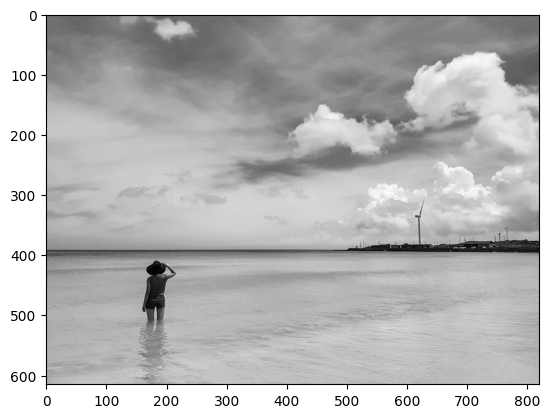

In [11]:
plt.imshow(image_gray, cmap='gray')

# 1. 데이터 생성 및 전처리

In [3]:
mnist.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [5]:
print(y_train[0])
for row in X_train[0]:
    for pixcel in row:
        print('{:3.0f}'.format(pixcel), end='')
    print()

5
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0  0  0  0

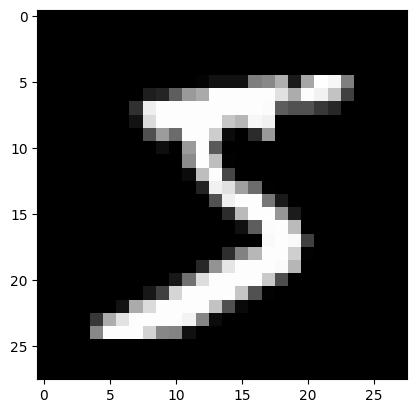

In [6]:
plt.imshow(X_train[0], cmap='gray')

In [7]:
#학습셋(6만개) -> 훈련셋(5만개) -> 검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [24]:
#학습셋(5만개:fit용), 검증셋(만:fit용), 테스트셋(만:평가용)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(50000, 28, 28) (50000,)
(10000, 28, 28) (10000,)
(10000, 28, 28) (10000,)


In [25]:
# 입력(독립)변수 (n, 28,28) -> (n, 784) -> 실수형변환 -> 스케일조정(255.0으로 나눠)
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [26]:
# 훈련셋5만개 -> 700개, 테스트셋1만개 -> 300개 추출(목적 : 학습시간 절약), 테스트셋은 그대로
train_idx = np.random.choice(50000, 700)
val_idx  = np.random.choice(10000, 300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
test_X = X_test
train_X.shape, y_train.shape, val_X.shape, y_val.shape

((700, 784), (700,), (300, 784), (300,))

In [37]:
#타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train,10)
val_Y = to_categorical(y_val)
test_Y = to_categorical(y_test)
print(y_train[:2])
print(train_Y[:2])

[1 8]
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]


In [31]:
#데이터 처리 전 작업
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
train_idx = np.random.choice(50000, 700)
val_idx  = np.random.choice(10000, 300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
#타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train,10)
val_Y = to_categorical(y_val)
test_Y = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

((700, 784), (700, 10), (300, 784), (300, 10), (10000, 784), (10000, 10))

# 2. 모델 구성

In [32]:
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 1570      
                                                                 
 dense_1 (Dense)             (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


# 3. 학습과정 설정

In [33]:
model.compile(loss='categorical_crossentropy', #sqarse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])

# 4. 모델 학습

In [34]:
%%time
hist = model.fit(train_X, train_Y, #훈련데이터
                epochs=500, #학습횟수
                batch_size=100, #한번에 읽어들이는 데이터 양
                validation_data=(val_X, val_Y) # 검증데이터
                )

Epoch 1/500
7/7 [==============================] - 1s 33ms/step - loss: 2.3075 - accuracy: 0.0671 - val_loss: 2.2959 - val_accuracy: 0.0867
Epoch 2/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2946 - accuracy: 0.0986 - val_loss: 2.2899 - val_accuracy: 0.0933
Epoch 3/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2876 - accuracy: 0.1057 - val_loss: 2.2774 - val_accuracy: 0.0900
Epoch 4/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2782 - accuracy: 0.0943 - val_loss: 2.2600 - val_accuracy: 0.0833
Epoch 5/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2640 - accuracy: 0.0971 - val_loss: 2.2416 - val_accuracy: 0.1000
Epoch 6/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2455 - accuracy: 0.1114 - val_loss: 2.2097 - val_accuracy: 0.1167
Epoch 7/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2185 - accuracy: 0.1371 - val_loss: 2.1739 - val_accuracy: 0.2167
Epoch 8/500
7/7 [=========

7/7 [==============================] - 0s 7ms/step - loss: 1.6154 - accuracy: 0.4300 - val_loss: 1.6571 - val_accuracy: 0.4533
Epoch 60/500
7/7 [==============================] - 0s 9ms/step - loss: 1.6083 - accuracy: 0.4329 - val_loss: 1.6536 - val_accuracy: 0.4500
Epoch 61/500
7/7 [==============================] - 0s 7ms/step - loss: 1.6027 - accuracy: 0.4314 - val_loss: 1.6502 - val_accuracy: 0.4567
Epoch 62/500
7/7 [==============================] - 0s 7ms/step - loss: 1.5973 - accuracy: 0.4329 - val_loss: 1.6458 - val_accuracy: 0.4567
Epoch 63/500
7/7 [==============================] - 0s 7ms/step - loss: 1.5908 - accuracy: 0.4343 - val_loss: 1.6420 - val_accuracy: 0.4567
Epoch 64/500
7/7 [==============================] - 0s 7ms/step - loss: 1.5861 - accuracy: 0.4343 - val_loss: 1.6384 - val_accuracy: 0.4567
Epoch 65/500
7/7 [==============================] - 0s 7ms/step - loss: 1.5803 - accuracy: 0.4357 - val_loss: 1.6337 - val_accuracy: 0.4567
Epoch 66/500
7/7 [===============

7/7 [==============================] - 0s 7ms/step - loss: 1.3718 - accuracy: 0.4814 - val_loss: 1.4903 - val_accuracy: 0.4800
Epoch 118/500
7/7 [==============================] - 0s 6ms/step - loss: 1.3684 - accuracy: 0.4843 - val_loss: 1.4904 - val_accuracy: 0.4833
Epoch 119/500
7/7 [==============================] - 0s 7ms/step - loss: 1.3654 - accuracy: 0.4886 - val_loss: 1.4862 - val_accuracy: 0.4767
Epoch 120/500
7/7 [==============================] - 0s 6ms/step - loss: 1.3622 - accuracy: 0.4900 - val_loss: 1.4842 - val_accuracy: 0.4800
Epoch 121/500
7/7 [==============================] - 0s 7ms/step - loss: 1.3588 - accuracy: 0.4929 - val_loss: 1.4846 - val_accuracy: 0.4833
Epoch 122/500
7/7 [==============================] - 0s 7ms/step - loss: 1.3561 - accuracy: 0.4914 - val_loss: 1.4817 - val_accuracy: 0.4833
Epoch 123/500
7/7 [==============================] - 0s 7ms/step - loss: 1.3529 - accuracy: 0.4943 - val_loss: 1.4796 - val_accuracy: 0.4833
Epoch 124/500
7/7 [========

7/7 [==============================] - 0s 7ms/step - loss: 1.2158 - accuracy: 0.5486 - val_loss: 1.4072 - val_accuracy: 0.5333
Epoch 176/500
7/7 [==============================] - 0s 7ms/step - loss: 1.2131 - accuracy: 0.5514 - val_loss: 1.4057 - val_accuracy: 0.5400
Epoch 177/500
7/7 [==============================] - 0s 7ms/step - loss: 1.2107 - accuracy: 0.5500 - val_loss: 1.4073 - val_accuracy: 0.5333
Epoch 178/500
7/7 [==============================] - 0s 6ms/step - loss: 1.2084 - accuracy: 0.5529 - val_loss: 1.4062 - val_accuracy: 0.5333
Epoch 179/500
7/7 [==============================] - 0s 7ms/step - loss: 1.2057 - accuracy: 0.5529 - val_loss: 1.4038 - val_accuracy: 0.5367
Epoch 180/500
7/7 [==============================] - 0s 6ms/step - loss: 1.2033 - accuracy: 0.5571 - val_loss: 1.4026 - val_accuracy: 0.5400
Epoch 181/500
7/7 [==============================] - 0s 7ms/step - loss: 1.2009 - accuracy: 0.5614 - val_loss: 1.4017 - val_accuracy: 0.5433
Epoch 182/500
7/7 [========

7/7 [==============================] - 0s 7ms/step - loss: 1.0865 - accuracy: 0.6300 - val_loss: 1.3815 - val_accuracy: 0.5567
Epoch 234/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0843 - accuracy: 0.6271 - val_loss: 1.3809 - val_accuracy: 0.5467
Epoch 235/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0827 - accuracy: 0.6271 - val_loss: 1.3810 - val_accuracy: 0.5500
Epoch 236/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0806 - accuracy: 0.6314 - val_loss: 1.3803 - val_accuracy: 0.5500
Epoch 237/500
7/7 [==============================] - 0s 8ms/step - loss: 1.0783 - accuracy: 0.6300 - val_loss: 1.3795 - val_accuracy: 0.5433
Epoch 238/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0764 - accuracy: 0.6314 - val_loss: 1.3807 - val_accuracy: 0.5467
Epoch 239/500
7/7 [==============================] - 0s 8ms/step - loss: 1.0747 - accuracy: 0.6343 - val_loss: 1.3796 - val_accuracy: 0.5467
Epoch 240/500
7/7 [========

7/7 [==============================] - 0s 6ms/step - loss: 0.9885 - accuracy: 0.6686 - val_loss: 1.3947 - val_accuracy: 0.5267
Epoch 292/500
7/7 [==============================] - 0s 8ms/step - loss: 0.9872 - accuracy: 0.6729 - val_loss: 1.3937 - val_accuracy: 0.5167
Epoch 293/500
7/7 [==============================] - 0s 8ms/step - loss: 0.9856 - accuracy: 0.6686 - val_loss: 1.3985 - val_accuracy: 0.5300
Epoch 294/500
7/7 [==============================] - 0s 8ms/step - loss: 0.9847 - accuracy: 0.6700 - val_loss: 1.3953 - val_accuracy: 0.5233
Epoch 295/500
7/7 [==============================] - 0s 8ms/step - loss: 0.9827 - accuracy: 0.6686 - val_loss: 1.3966 - val_accuracy: 0.5233
Epoch 296/500
7/7 [==============================] - 0s 8ms/step - loss: 0.9815 - accuracy: 0.6686 - val_loss: 1.3988 - val_accuracy: 0.5300
Epoch 297/500
7/7 [==============================] - 0s 8ms/step - loss: 0.9802 - accuracy: 0.6743 - val_loss: 1.3974 - val_accuracy: 0.5167
Epoch 298/500
7/7 [========

7/7 [==============================] - 0s 6ms/step - loss: 0.9141 - accuracy: 0.7029 - val_loss: 1.4299 - val_accuracy: 0.4967
Epoch 350/500
7/7 [==============================] - 0s 6ms/step - loss: 0.9133 - accuracy: 0.7000 - val_loss: 1.4323 - val_accuracy: 0.4967
Epoch 351/500
7/7 [==============================] - 0s 7ms/step - loss: 0.9120 - accuracy: 0.7043 - val_loss: 1.4293 - val_accuracy: 0.4967
Epoch 352/500
7/7 [==============================] - 0s 7ms/step - loss: 0.9114 - accuracy: 0.7029 - val_loss: 1.4302 - val_accuracy: 0.4967
Epoch 353/500
7/7 [==============================] - 0s 6ms/step - loss: 0.9104 - accuracy: 0.7057 - val_loss: 1.4361 - val_accuracy: 0.5033
Epoch 354/500
7/7 [==============================] - 0s 6ms/step - loss: 0.9093 - accuracy: 0.7029 - val_loss: 1.4318 - val_accuracy: 0.4967
Epoch 355/500
7/7 [==============================] - 0s 6ms/step - loss: 0.9084 - accuracy: 0.7057 - val_loss: 1.4331 - val_accuracy: 0.4933
Epoch 356/500
7/7 [========

7/7 [==============================] - 0s 6ms/step - loss: 0.8566 - accuracy: 0.7229 - val_loss: 1.4796 - val_accuracy: 0.4867
Epoch 408/500
7/7 [==============================] - 0s 6ms/step - loss: 0.8550 - accuracy: 0.7229 - val_loss: 1.4841 - val_accuracy: 0.4833
Epoch 409/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8543 - accuracy: 0.7229 - val_loss: 1.4853 - val_accuracy: 0.4900
Epoch 410/500
7/7 [==============================] - 0s 6ms/step - loss: 0.8532 - accuracy: 0.7271 - val_loss: 1.4844 - val_accuracy: 0.4867
Epoch 411/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8521 - accuracy: 0.7271 - val_loss: 1.4877 - val_accuracy: 0.4900
Epoch 412/500
7/7 [==============================] - 0s 6ms/step - loss: 0.8513 - accuracy: 0.7243 - val_loss: 1.4872 - val_accuracy: 0.4867
Epoch 413/500
7/7 [==============================] - 0s 6ms/step - loss: 0.8505 - accuracy: 0.7300 - val_loss: 1.4892 - val_accuracy: 0.4900
Epoch 414/500
7/7 [========

7/7 [==============================] - 0s 7ms/step - loss: 0.8055 - accuracy: 0.7414 - val_loss: 1.5612 - val_accuracy: 0.4933
Epoch 466/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8049 - accuracy: 0.7443 - val_loss: 1.5584 - val_accuracy: 0.4933
Epoch 467/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8045 - accuracy: 0.7400 - val_loss: 1.5553 - val_accuracy: 0.4933
Epoch 468/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8027 - accuracy: 0.7429 - val_loss: 1.5667 - val_accuracy: 0.4933
Epoch 469/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8024 - accuracy: 0.7429 - val_loss: 1.5605 - val_accuracy: 0.4933
Epoch 470/500
7/7 [==============================] - 0s 6ms/step - loss: 0.8019 - accuracy: 0.7429 - val_loss: 1.5630 - val_accuracy: 0.4900
Epoch 471/500
7/7 [==============================] - 0s 7ms/step - loss: 0.8007 - accuracy: 0.7443 - val_loss: 1.5658 - val_accuracy: 0.4900
Epoch 472/500
7/7 [========

In [35]:
#학습 과정 살펴보기
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

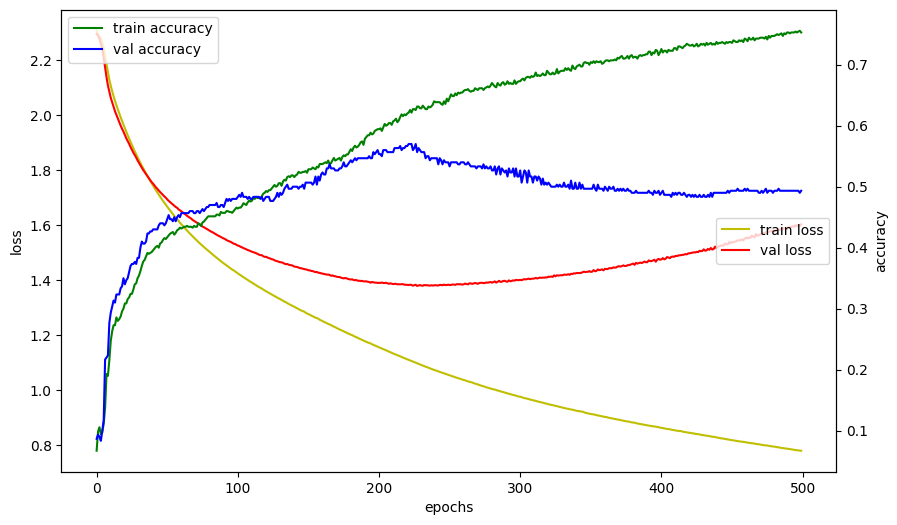

In [36]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [37]:
#모델 평가하기
loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss: ', loss_and_metrics[0])
print('accuracy: ', loss_and_metrics[1])

loss:  1.822248101234436
accuracy:  0.5049999952316284


# ※위 모델(DNN)의 accuracy 늘리기
- 데이터 확보
- 모델 수정(레이어 추가, unit수 증가)
- 과적합 방지(validation data추가, dropout, 활성화함수relu계열, tanh)
- epoch 조정
- optimizer변경

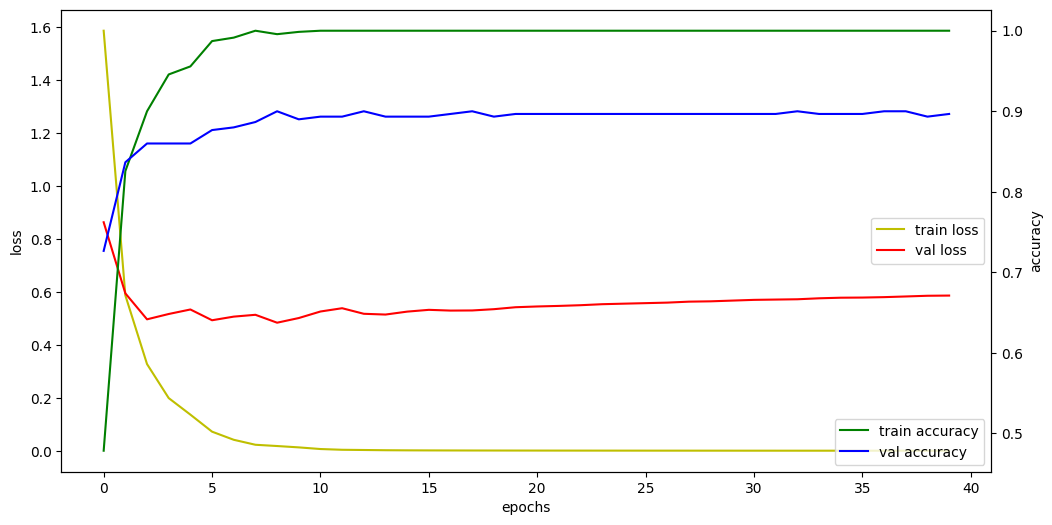

CPU times: total: 19 s
Wall time: 5.95 s


In [8]:
%%time
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
#50000개 => 700개 / 10000개 -> 300
train_idx = np.random.choice(50000, 700)
val_idx  = np.random.choice(10000, 300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
#모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=1024, activation='relu'))
model.add(Dense(units=512, activation='relu'))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])

hist = model.fit(train_X, train_Y,
                epochs=40,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=0)
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()


In [9]:
#모델 평가하기
loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

loss : 0.4929196834564209
accuracy : 0.9006999731063843


In [11]:
#실제값
test_Y.argmax(axis=1) == y_test

array([ True,  True,  True, ...,  True,  True,  True])

In [15]:
#예측값
yhat = model.predict(test_X).argmax(axis=1)
yhat = np.argmax(model.predict(test_X), axis=1)
yhat

313/313 [==============================] - 1s 4ms/step


array([7, 2, 1, ..., 9, 5, 6], dtype=int64)

In [16]:
pd.crosstab(y_test,yhat)

col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,949,0,5,4,0,10,5,2,4,1
1,0,1106,2,2,2,1,7,0,15,0
2,17,4,876,31,22,0,21,21,37,3
3,7,3,13,896,1,25,4,20,32,9
4,4,0,2,0,883,0,14,0,15,64
5,25,2,2,38,18,723,29,6,43,6
6,22,3,9,1,2,4,915,0,2,0
7,4,15,33,6,11,0,1,915,2,41
8,9,8,6,24,11,23,19,20,849,5


In [20]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,yhat)

array([[ 949,    0,    5,    4,    0,   10,    5,    2,    4,    1],
       [   0, 1106,    2,    2,    2,    1,    7,    0,   15,    0],
       [  17,    4,  876,   31,   22,    0,   21,   21,   37,    3],
       [   7,    3,   13,  896,    1,   25,    4,   20,   32,    9],
       [   4,    0,    2,    0,  883,    0,   14,    0,   15,   64],
       [  25,    2,    2,   38,   18,  723,   29,    6,   43,    6],
       [  22,    3,    9,    1,    2,    4,  915,    0,    2,    0],
       [   4,   15,   33,    6,   11,    0,    1,  915,    2,   41],
       [   9,    8,    6,   24,   11,   23,   19,   20,  849,    5],
       [  14,    8,    3,    7,   44,    8,    2,   15,   13,  895]],
      dtype=int64)

In [21]:
#틀린 갯수
10000-10000*loss_and_metrics[1]

993.0002689361572

In [23]:
cnt = 0
for y, h in zip(y_test, yhat):
    if y != h:
        cnt +=1
print('틀린 갯수:',cnt)

틀린 갯수: 993


In [24]:
#모델 저장
model.save('data/08_mnist.h5')

# 콜백함수1 : 로그 출력

In [25]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

In [29]:
%%time
#매번 로그 출력하면 지저분해 질 수 있으니, 특정 epoch마다 로그 출력하도록 제한
class CustomHistory(Callback):
    def __init__(self): #생성자함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}):# 1epoch마다 자동 실행되는 함수
        self.epoch += 1 #epoch마다 self.epoch값을 1씩 증가
        if self.epoch%10 == 0:
            print('epoch:{}, loss:{}, acc:{}, val_loss:{}, val_acc:{}'.format(self.epoch,
                                                                             logs.get('loss'),
                                                                             logs.get('accurach','-'),
                                                                             logs.get('val_loss','-'),
                                                                             logs.get('val_accuracy','-')
                                                                             )
                 )
            
customHistory=CustomHistory()

(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
#50000개 => 700개 / 10000개 -> 300
train_idx = np.random.choice(50000, 700)
val_idx  = np.random.choice(10000, 300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
#모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
#학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
#학습
customHistory = CustomHistory()
hist = model.fit(train_X, train_Y,
                epochs=40,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=0,
                callbacks=[customHistory])#콜백함수

epoch:10, loss:2.067822217941284, acc:-, val_loss:2.0980663299560547, val_acc:0.27000001072883606
epoch:20, loss:1.9267054796218872, acc:-, val_loss:1.9691269397735596, val_acc:0.3166666626930237
epoch:30, loss:1.812602162361145, acc:-, val_loss:1.8695975542068481, val_acc:0.35333332419395447
epoch:40, loss:1.7294096946716309, acc:-, val_loss:1.8061909675598145, val_acc:0.3499999940395355
CPU times: total: 2.83 s
Wall time: 2.33 s


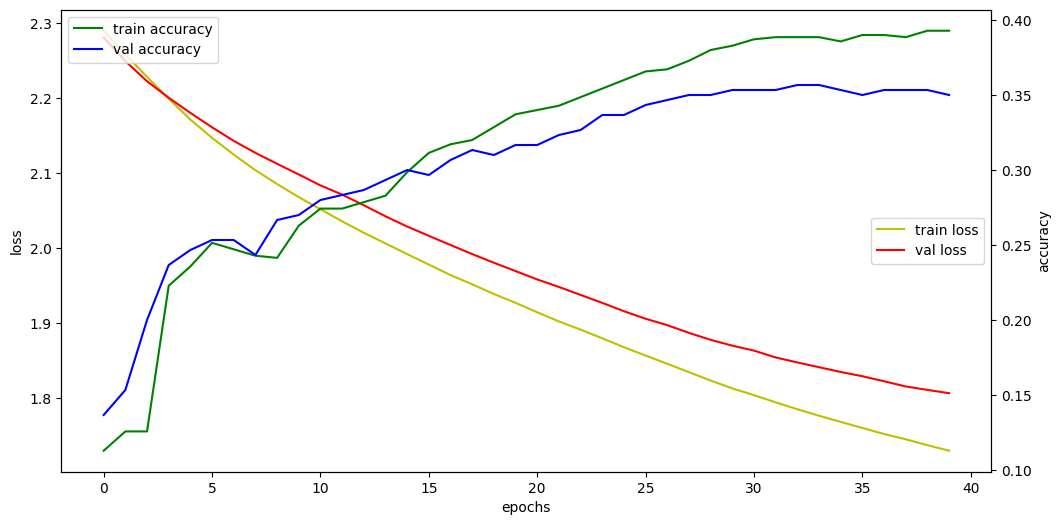

In [30]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()


# ※콜백함수2 : EarlyStopping
- val_loss값이 늘어지면 지정한 epoch를 다 수행하지 않고 조기 종료
- val_accuracy값이 감소하면 지정한 epoch를 다 수행하지 않고 조기 종료

In [32]:
#모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
#학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
#학습
#monitor기준으로 patience번 이상 안 좋은 데이터가 나오면 조기종료
earlystopping = EarlyStopping(monitor='val_accuracy', patience=2)
hist = model.fit(train_X, train_Y,
                epochs=40,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlystopping])#콜백함수

Epoch 1/40
7/7 [==============================] - 0s 25ms/step - loss: 2.3106 - accuracy: 0.0814 - val_loss: 2.3033 - val_accuracy: 0.1033
Epoch 2/40
7/7 [==============================] - 0s 7ms/step - loss: 2.2987 - accuracy: 0.1100 - val_loss: 2.2980 - val_accuracy: 0.1133
Epoch 3/40
7/7 [==============================] - 0s 7ms/step - loss: 2.2912 - accuracy: 0.1171 - val_loss: 2.2936 - val_accuracy: 0.1067
Epoch 4/40
7/7 [==============================] - 0s 6ms/step - loss: 2.2818 - accuracy: 0.1114 - val_loss: 2.2889 - val_accuracy: 0.1133


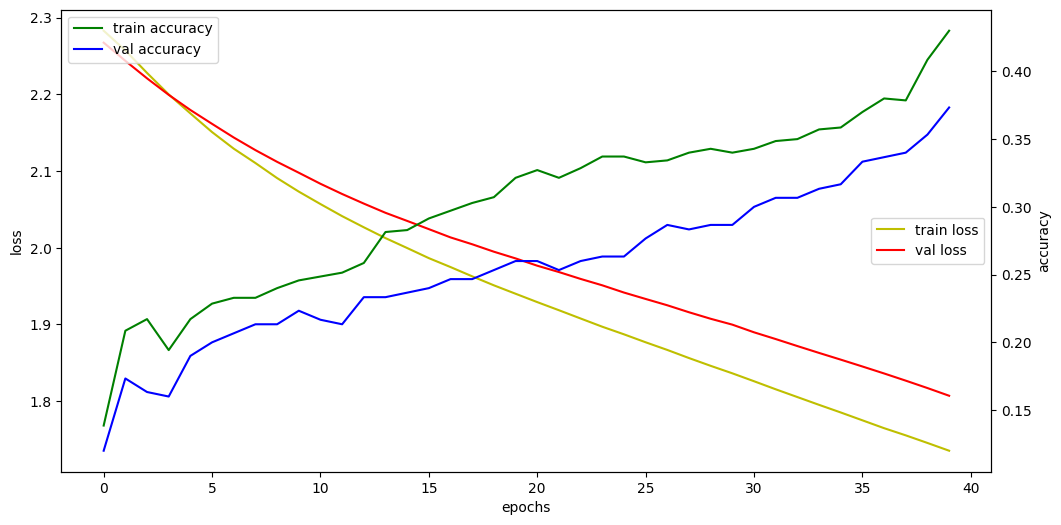

In [34]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()


# ※콜배함수3:ModelCheckpoint
- epoch마다 val_accurancy(val_loss, accuracy, loss)값이 좋을 때 모델을 자동 저장하는 콜백

In [36]:
#모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
#학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
#학습
#monitor기준으로 patience번 이상 안 좋은 데이터가 나오면 조기종료
earlystopping = EarlyStopping(monitor='val_accuracy', patience=10)
#모델 자동 저장 콜백
import os
model_save_folder = './model08/'
if not os.path.exists(model_save_folder): #폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'mist-{epoch:03d}-val{val_accuracy:.4f}.h5'
    
checkpoint = ModelCheckpoint(filepath=file, #저장경로
                             monitor='val_accuracy',#모니터링할 지표
                             save_best_only=True, #모니터링 지표가 개선된 경우만 저장
                             mode = 'max',#값이 클수록 저장
                             verbose=1 #저장시 로그 출력
                            )

hist = model.fit(train_X, train_Y,
                epochs=40,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlystopping, checkpoint])#콜백함수

Epoch 1/40
1/7 [===>..........................] - ETA: 1s - loss: 2.3046 - accuracy: 0.1100
Epoch 1: val_accuracy improved from -inf to 0.13667, saving model to ./model08\mist-001-val0.1367.h5
7/7 [==============================] - 0s 30ms/step - loss: 2.2726 - accuracy: 0.1300 - val_loss: 2.2657 - val_accuracy: 0.1367
Epoch 2/40
1/7 [===>..........................] - ETA: 0s - loss: 2.2282 - accuracy: 0.2000
Epoch 2: val_accuracy improved from 0.13667 to 0.16333, saving model to ./model08\mist-002-val0.1633.h5
7/7 [==============================] - 0s 9ms/step - loss: 2.2212 - accuracy: 0.1786 - val_loss: 2.2152 - val_accuracy: 0.1633
Epoch 3/40
1/7 [===>..........................] - ETA: 0s - loss: 2.1805 - accuracy: 0.1800
Epoch 3: val_accuracy improved from 0.16333 to 0.17000, saving model to ./model08\mist-003-val0.1700.h5
7/7 [==============================] - 0s 10ms/step - loss: 2.1701 - accuracy: 0.1843 - val_loss: 2.1689 - val_accuracy: 0.1700
Epoch 4/40
1/7 [===>............

1/7 [===>..........................] - ETA: 0s - loss: 1.6325 - accuracy: 0.3900
Epoch 28: val_accuracy did not improve from 0.30000
7/7 [==============================] - 0s 8ms/step - loss: 1.7369 - accuracy: 0.3143 - val_loss: 1.7906 - val_accuracy: 0.2933
Epoch 29/40
1/7 [===>..........................] - ETA: 0s - loss: 1.7137 - accuracy: 0.3800
Epoch 29: val_accuracy did not improve from 0.30000
7/7 [==============================] - 0s 7ms/step - loss: 1.7285 - accuracy: 0.3229 - val_loss: 1.7838 - val_accuracy: 0.2867
Epoch 30/40
1/7 [===>..........................] - ETA: 0s - loss: 1.6281 - accuracy: 0.3900
Epoch 30: val_accuracy did not improve from 0.30000
7/7 [==============================] - 0s 7ms/step - loss: 1.7196 - accuracy: 0.3257 - val_loss: 1.7766 - val_accuracy: 0.2967
Epoch 31/40
1/7 [===>..........................] - ETA: 0s - loss: 1.7607 - accuracy: 0.3000
Epoch 31: val_accuracy improved from 0.30000 to 0.31667, saving model to ./model08\mist-031-val0.3167.h